100 equilibria, use one free parameter combination (or maybe 5) and then run the EPEDNN loop and make a plot of pressure predicted vs. pfile pressure at psiN=1-delta and psiN=0.85

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve
from src.load_equil import initialize_inputs

from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [ ]:
verbose = True
verbose_sc = False

# Output data and files
ne_success_fp = 'success_profloop'

# Scan parameters
x_res = 20
eped_tol_max = 1e-5
free_params = {
    'alpha_crit': 0.1,
    'C_KBM': 1,
    'De_chie_etg': 0.1,
    'nFC_x0': 3.16228e15,
    'ncx_x0_ratio': 17.783
}

# Equilibria parameters
equil_num = 2
kprof_loc = 'pfile'
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks')
pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles')
# geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode')
# pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

In [3]:
# Load in equilibria
equilibria = initialize_inputs(equil_num, geqdsk_dir, pfile_dir, p_filetype=kprof_loc)

Selected 2 g/pfile file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g150840.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p150840.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g152960.03500
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p152960.03500


In [4]:
MHD_FP = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158091.01935') # filepath to MHD paramter file
KPROF_FP = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158091.01935')
equilibria = [(MHD_FP, KPROF_FP)]

In [5]:
def pres_pred(ped_wid, gfile_pres, gfile_pres_grid):
    """
    Calculate pedestal pressure from pedestal width and MHD equilibrium file.
    """
    psiN_top = 1 - ped_wid
    return np.interp(psiN_top, gfile_pres_grid, gfile_pres)

/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158091.01935
Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
[nondim] reference scales:
  L  = 5.1588e-02 m
  n0 = 1.0954e+19 m^-3
  T0 = 4.9697e-17 J  (310.182 eV)
  S0 = 3.8846e-14 m^3/s
  tau    = 2.3500e-06 s
  [V]_0  = 2.1952e+04 m/s
  [D]_0  = 1.1325e+03 m^2/s
[nondim] x_inner          = -5.1588e-02 m
[nondim] ne_inner_bc      = 'neumann'
[nondim] ne(x_inner)      = 2.448e+19 m^-3 (p-file)
[nondim] dne/dx(x_inner)  = -5.145e+19 m^-4 (p-file)
[nondim] hat_ne(0)        = 1.0
[nondim] hat_ne(-1)       = 2.235e+00
[nondim] hat_nFC(0)       = 2.887e-04
[nondim] hat_nCX(0)       = 5.134e-03
[nondim] hat_dne/dxhat(-1)= -2.423e-01


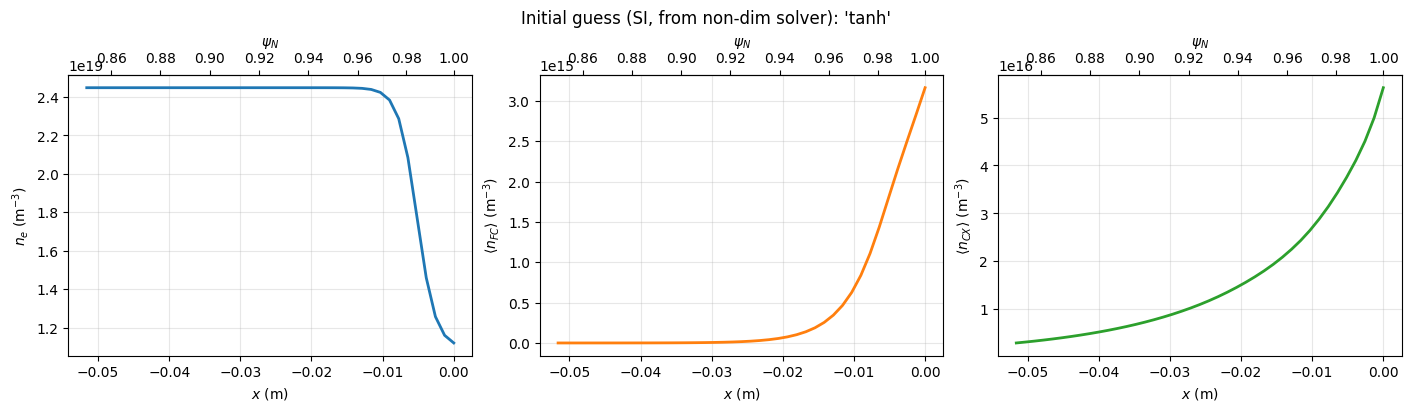

[picard] it   1: |dne|_rel = 5.016e-01, alpha_bar = 1.8542, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 1.908e-01, alpha_bar = 1.4926, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 9.881e-02, alpha_bar = 1.6445, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 4.202e-02, alpha_bar = 1.5736, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 1.954e-02, alpha_bar = 1.6052, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 8.731e-03, alpha_bar = 1.5908, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 3.973e-03, alpha_bar = 1.5973, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 1.793e-03, alpha_bar = 1.5944, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 8.119e-04, alpha_bar = 1.5957, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 3.671e-04, alpha_bar = 1.5951, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 1.661e-04, alpha_bar = 1.5954, frac(alpha>crit) = 1

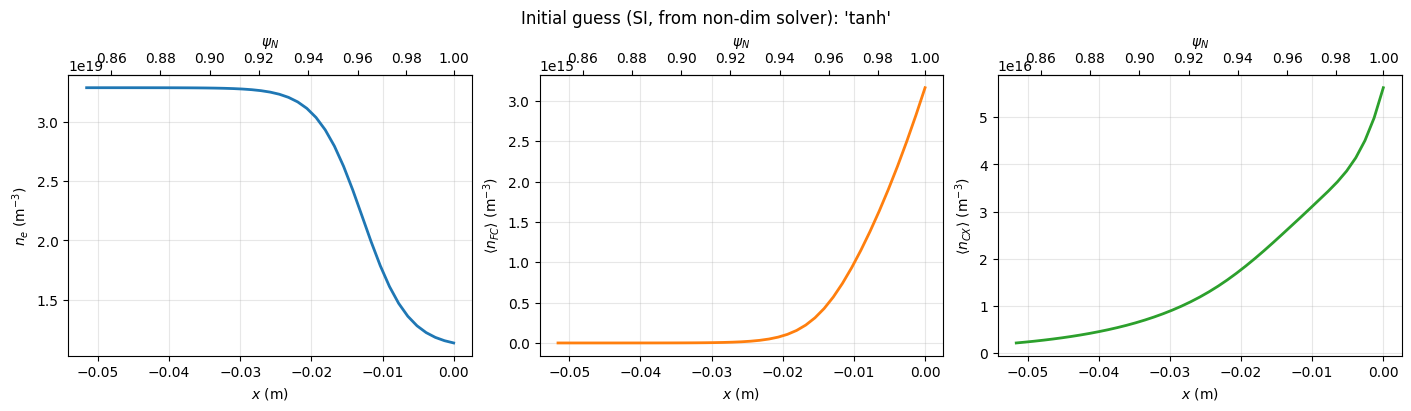

[picard] it   1: |dne|_rel = 2.865e-01, alpha_bar = 1.8875, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 6.465e-02, alpha_bar = 1.7627, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 2.967e-02, alpha_bar = 1.8163, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 1.280e-02, alpha_bar = 1.7925, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 5.677e-03, alpha_bar = 1.8029, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 2.487e-03, alpha_bar = 1.7983, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 1.095e-03, alpha_bar = 1.8003, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 4.812e-04, alpha_bar = 1.7994, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 2.116e-04, alpha_bar = 1.7998, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 9.304e-05, alpha_bar = 1.7996, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 4.091e-05, alpha_bar = 1.7997, frac(alpha>crit) = 1

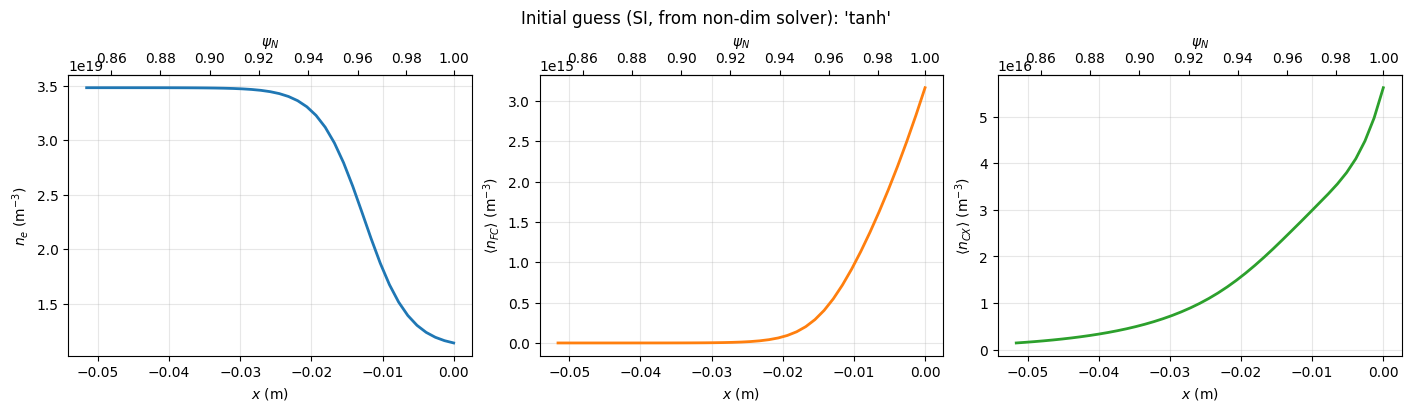

[picard] it   1: |dne|_rel = 2.650e-01, alpha_bar = 1.7919, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 5.152e-02, alpha_bar = 1.6974, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 2.366e-02, alpha_bar = 1.7386, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 1.033e-02, alpha_bar = 1.7202, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 4.614e-03, alpha_bar = 1.7283, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 2.040e-03, alpha_bar = 1.7247, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 9.058e-04, alpha_bar = 1.7263, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 4.015e-04, alpha_bar = 1.7256, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 1.781e-04, alpha_bar = 1.7259, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 7.900e-05, alpha_bar = 1.7258, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 3.504e-05, alpha_bar = 1.7258, frac(alpha>crit) = 1

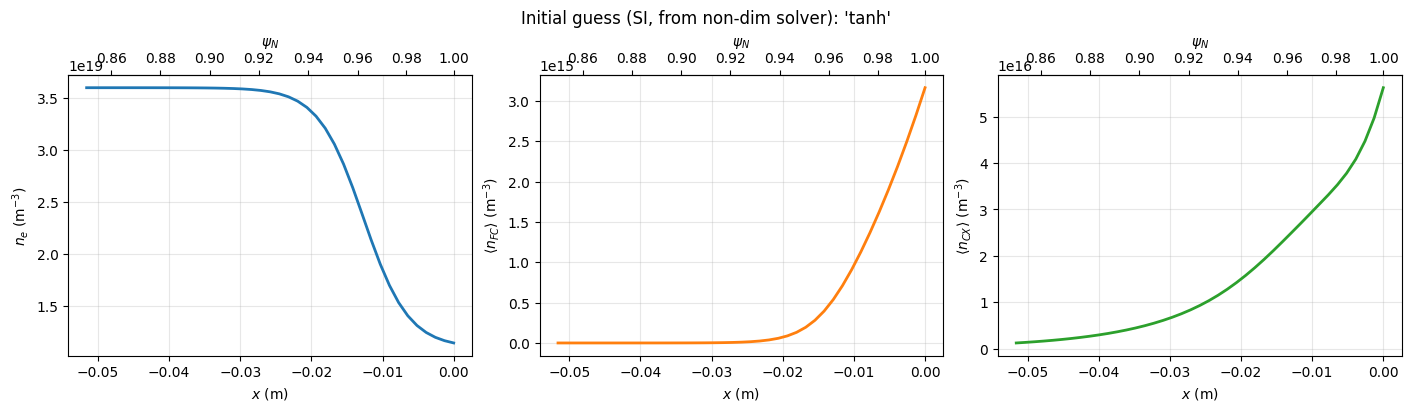

[picard] it   1: |dne|_rel = 2.468e-01, alpha_bar = 1.7530, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.641e-02, alpha_bar = 1.6876, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.653e-02, alpha_bar = 1.7162, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 7.245e-03, alpha_bar = 1.7035, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 3.225e-03, alpha_bar = 1.7091, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.426e-03, alpha_bar = 1.7066, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 6.322e-04, alpha_bar = 1.7077, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.800e-04, alpha_bar = 1.7072, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 1.241e-04, alpha_bar = 1.7075, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 5.497e-05, alpha_bar = 1.7074, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 2.436e-05, alpha_bar = 1.7074, frac(alpha>crit) = 1

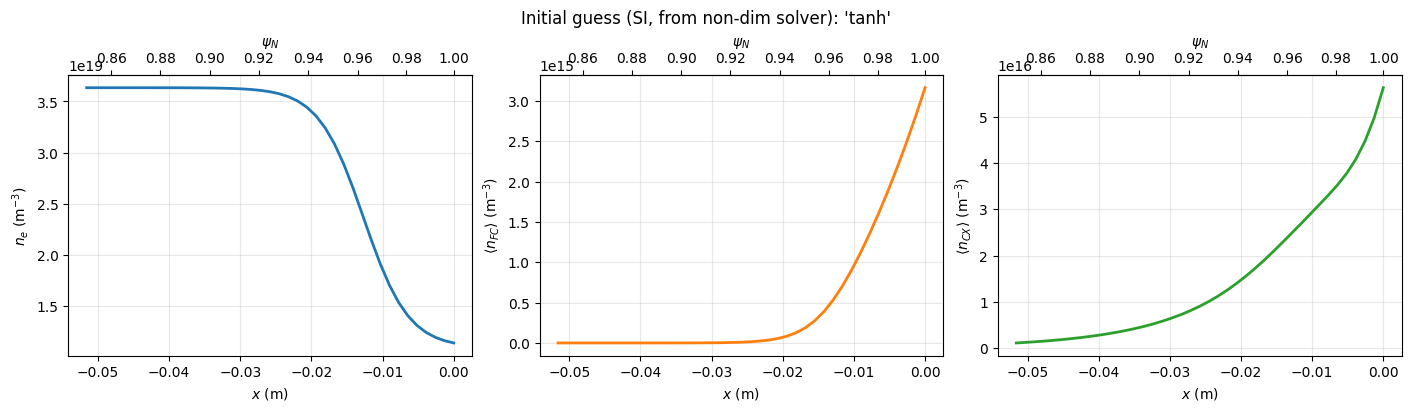

[picard] it   1: |dne|_rel = 2.435e-01, alpha_bar = 1.7436, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.353e-02, alpha_bar = 1.6837, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.517e-02, alpha_bar = 1.7099, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 6.644e-03, alpha_bar = 1.6983, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 2.952e-03, alpha_bar = 1.7034, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.303e-03, alpha_bar = 1.7011, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 5.769e-04, alpha_bar = 1.7021, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.551e-04, alpha_bar = 1.7017, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 1.129e-04, alpha_bar = 1.7019, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 4.992e-05, alpha_bar = 1.7018, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 2.208e-05, alpha_bar = 1.7018, frac(alpha>crit) = 1

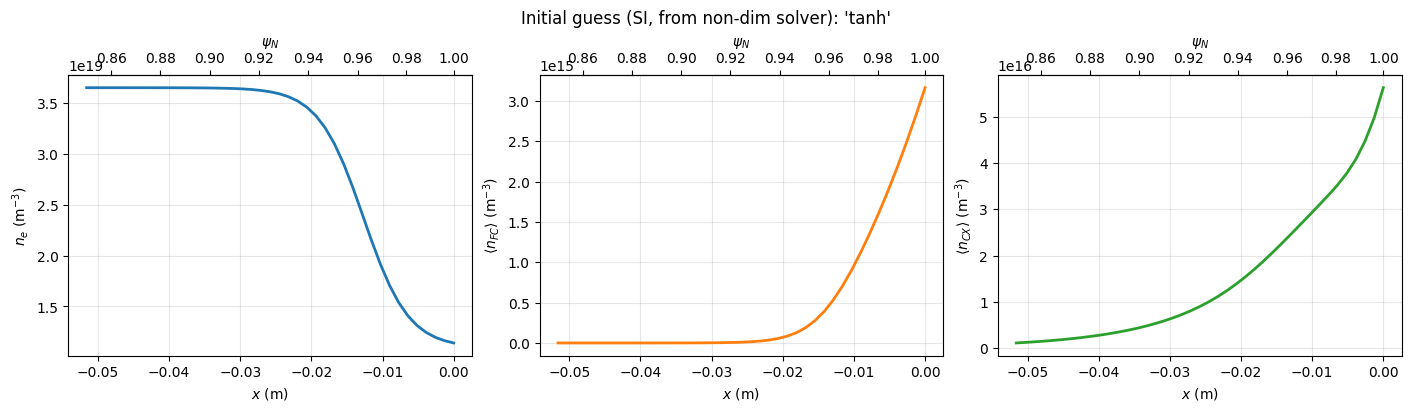

[picard] it   1: |dne|_rel = 2.424e-01, alpha_bar = 1.7417, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.238e-02, alpha_bar = 1.6840, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.461e-02, alpha_bar = 1.7092, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 6.387e-03, alpha_bar = 1.6980, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 2.831e-03, alpha_bar = 1.7030, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.247e-03, alpha_bar = 1.7008, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 5.509e-04, alpha_bar = 1.7017, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.431e-04, alpha_bar = 1.7013, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 1.073e-04, alpha_bar = 1.7015, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 4.737e-05, alpha_bar = 1.7014, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 2.091e-05, alpha_bar = 1.7015, frac(alpha>crit) = 1

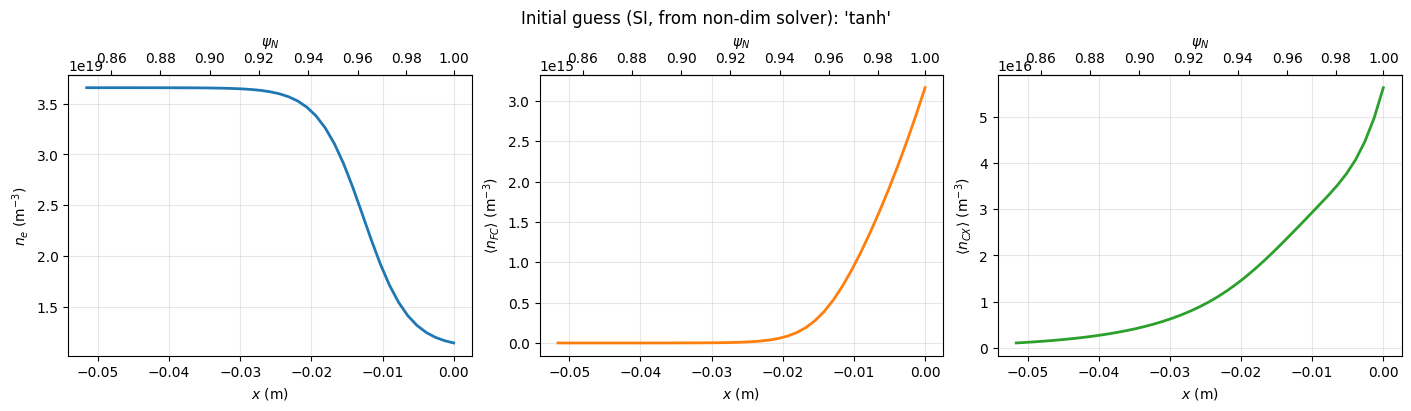

[picard] it   1: |dne|_rel = 2.419e-01, alpha_bar = 1.7416, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.190e-02, alpha_bar = 1.6848, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.435e-02, alpha_bar = 1.7095, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 6.263e-03, alpha_bar = 1.6986, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 2.770e-03, alpha_bar = 1.7034, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.217e-03, alpha_bar = 1.7013, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 5.367e-04, alpha_bar = 1.7022, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.363e-04, alpha_bar = 1.7018, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 1.041e-04, alpha_bar = 1.7020, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 4.584e-05, alpha_bar = 1.7019, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 2.019e-05, alpha_bar = 1.7019, frac(alpha>crit) = 1

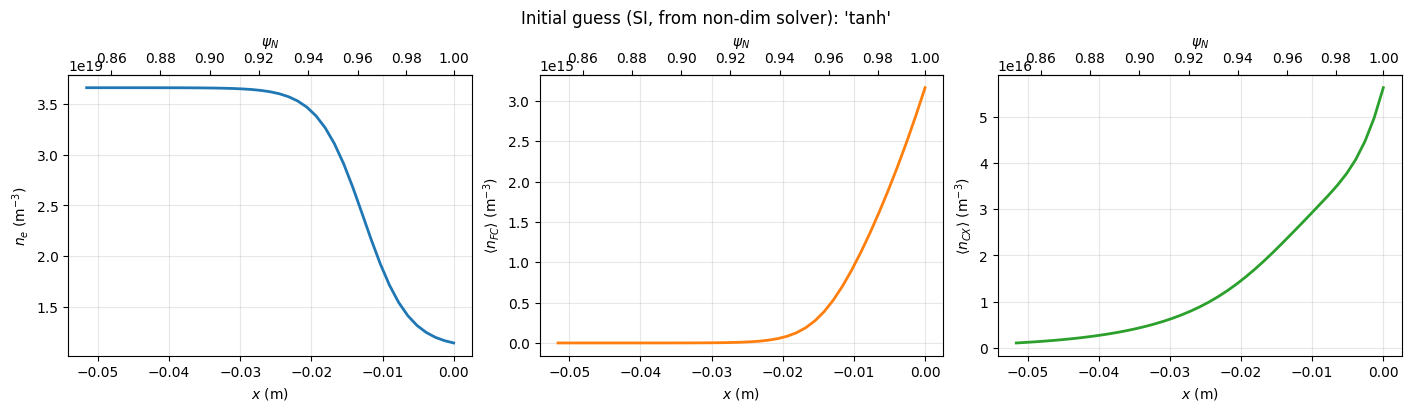

[picard] it   1: |dne|_rel = 2.414e-01, alpha_bar = 1.7418, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.154e-02, alpha_bar = 1.6856, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.416e-02, alpha_bar = 1.7101, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 6.166e-03, alpha_bar = 1.6993, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 2.722e-03, alpha_bar = 1.7040, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.194e-03, alpha_bar = 1.7019, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 5.253e-04, alpha_bar = 1.7028, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.308e-04, alpha_bar = 1.7024, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 1.014e-04, alpha_bar = 1.7026, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 4.457e-05, alpha_bar = 1.7025, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 0.000e+00, alpha_bar = 1.7025, frac(alpha>crit) = 1

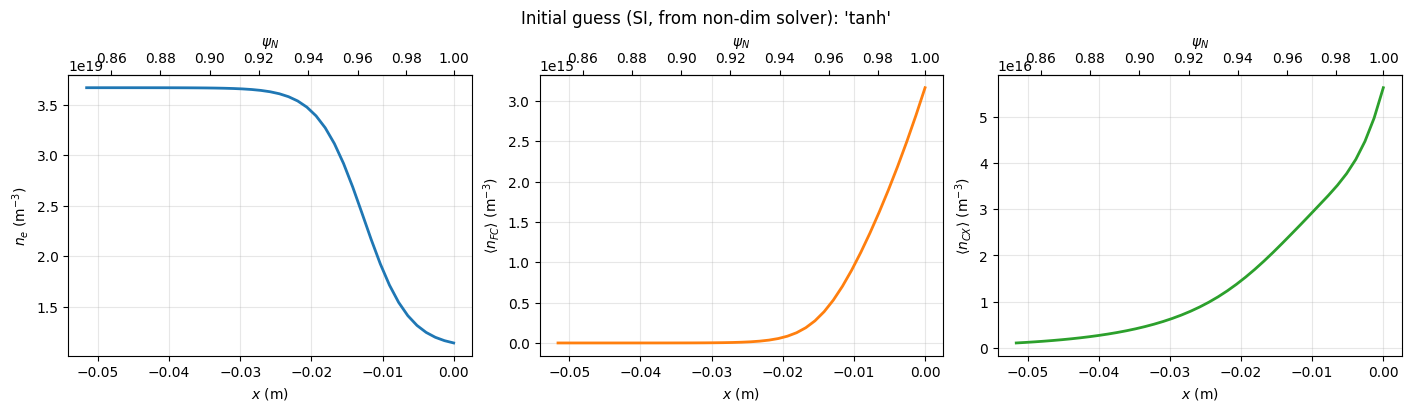

[picard] it   1: |dne|_rel = 2.414e-01, alpha_bar = 1.7435, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.156e-02, alpha_bar = 1.6872, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.413e-02, alpha_bar = 1.7116, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 6.142e-03, alpha_bar = 1.7008, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 2.706e-03, alpha_bar = 1.7055, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.184e-03, alpha_bar = 1.7035, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 5.197e-04, alpha_bar = 1.7044, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.278e-04, alpha_bar = 1.7040, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 9.990e-05, alpha_bar = 1.7042, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 4.380e-05, alpha_bar = 1.7041, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 0.000e+00, alpha_bar = 1.7041, frac(alpha>crit) = 1

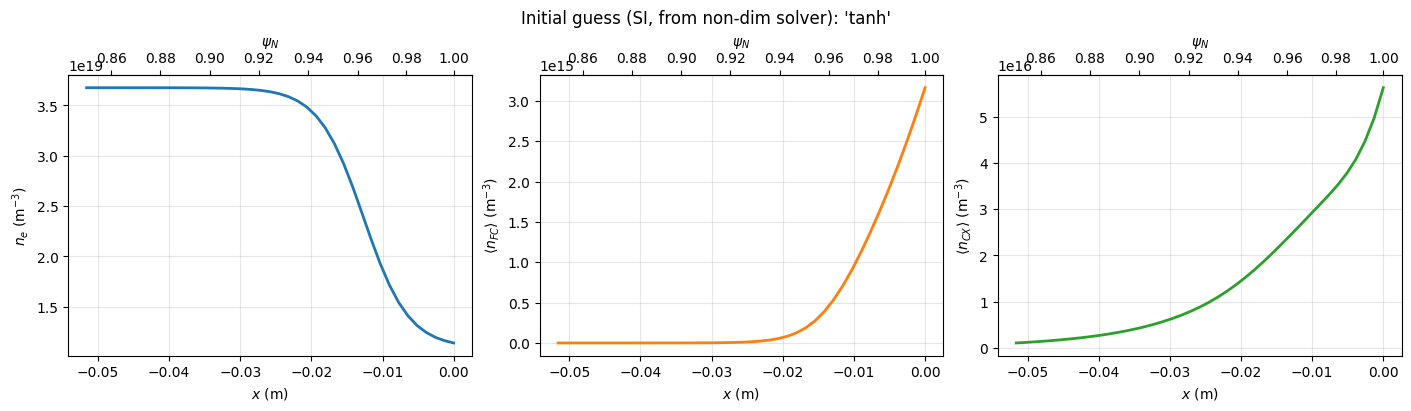

[picard] it   1: |dne|_rel = 2.412e-01, alpha_bar = 1.7445, frac(alpha>crit) = 1.00, KBM ON
[picard] it   2: |dne|_rel = 3.140e-02, alpha_bar = 1.6884, frac(alpha>crit) = 1.00, KBM ON
[picard] it   3: |dne|_rel = 1.403e-02, alpha_bar = 1.7127, frac(alpha>crit) = 1.00, KBM ON
[picard] it   4: |dne|_rel = 6.083e-03, alpha_bar = 1.7020, frac(alpha>crit) = 1.00, KBM ON
[picard] it   5: |dne|_rel = 2.673e-03, alpha_bar = 1.7067, frac(alpha>crit) = 1.00, KBM ON
[picard] it   6: |dne|_rel = 1.168e-03, alpha_bar = 1.7046, frac(alpha>crit) = 1.00, KBM ON
[picard] it   7: |dne|_rel = 5.112e-04, alpha_bar = 1.7055, frac(alpha>crit) = 1.00, KBM ON
[picard] it   8: |dne|_rel = 2.236e-04, alpha_bar = 1.7051, frac(alpha>crit) = 1.00, KBM ON
[picard] it   9: |dne|_rel = 9.783e-05, alpha_bar = 1.7053, frac(alpha>crit) = 1.00, KBM ON
[picard] it  10: |dne|_rel = 4.280e-05, alpha_bar = 1.7052, frac(alpha>crit) = 1.00, KBM ON
[picard] it  11: |dne|_rel = 0.000e+00, alpha_bar = 1.7052, frac(alpha>crit) = 1

In [ ]:
# For each equilbrium, call profiles_loop_solve() from profiles_loop_solve.py
failed=[]
success=[]
for mhd_fp, kprof_fp in equilibria:
    # try:
        print(mhd_fp)
        ped_wid, ped_h_out, gfile_pres, gfile_pres_grid = profiles_loop_solve(
            MHD_FP = mhd_fp,
            kprof_loc = kprof_loc,
            KPROF_FP = kprof_fp,
            ne_success_fp = ne_success_fp,
            x_res = x_res,
            eped_tol_max = eped_tol_max,
            free_params = free_params,
            kbm_treatment = kbm_treatment,
            kbm_gate_eps = kbm_gate_eps,
            picard_gate_mode = picard_gate_mode,
            picard_max_it = picard_max_it,
            picard_rtol = picard_rtol,
            picard_relax = picard_relax,
            verbose = verbose,
            verbose_sc = verbose_sc,
        )
        p_gfile = pres_pred(ped_wid, gfile_pres, gfile_pres_grid)
        out_dict = {
            'mhd_fp': mhd_fp,
            'kprof_fp': kprof_fp,
            'ped_h': ped_h_out,
            'ped_wid': ped_wid,
            'p_gfile': p_gfile,
        }
        success.append(out_dict)
    # except Exception as e:
    #     failed.append(mhd_fp)

In [ ]:
# Plot pressure predicted (p_out) vs. geqdsk pressure at psiN=1-delta and psiN=0.85 for all equilibria
fig, ax = plt.subplots()
for out_dict in success:
    ax.plot(out_dict['p_gfile'] / 1e6, out_dict['ped_h'],'o')
ax.plot([0, 0.015], [0, 0.015], 'k--')
ax.set_xlabel('GEQDSK pressure [MPa]')
ax.set_ylabel('Predicted pressure [MPa]')